# SVM Smoke Detection Model

This notebook trains and evaluates a Support Vector Machine classifier for smoke-related event classification. It follows the same prepared data, train/test split, scaling, and evaluation structure used in the Random Forest and KNN notebooks.

SVM is included because it is a strong margin-based classifier that can separate classes using either linear or non-linear decision boundaries. This makes it useful for testing whether the sensor readings can be separated by a clear boundary between Normal, Cooking, and Fire cases.

#### 1. Imports
Import the libraries needed for data handling, plotting, scaling, SVM training, cross-validation, and evaluation.

In [32]:
# Import all libraries in one place.
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


#### 2. Settings
Define the input files, selected sensor features, class names, and random state so the workflow stays reproducible.

In [33]:
# Define files, feature columns, class names, and random state.
notebook_folder = Path('.').resolve()

iot_file = notebook_folder / 'iot_clean_data.xlsx'
blattmann_file = notebook_folder / 'blattmann_clean_data.xlsx'

feature_col = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']
class_names = ['Normal', 'Cooking', 'Fire']
random_state = 42


#### 3. Load Prepared Data
Load the cleaned IoT and Blattmann datasets. Blattmann smoke readings are remapped to the project class Fire so both datasets follow the same class structure.

In [34]:
# Load the prepared IoT and Blattmann datasets separately.
iot_data = pd.read_excel(iot_file)
blattmann_data = pd.read_excel(blattmann_file, sheet_name='Blattmann Processed')

if 'label' in blattmann_data.columns:
    blattmann_data = blattmann_data.rename(columns={'label': 'blattmann_label'})

blattmann_data['class_id'] = blattmann_data['blattmann_label'].map({
    'No Smoke': 0,
    'Smoke': 2,
    'Normal': 0,
    'Fire': 2,
    0: 0,
    2: 2,
})

blattmann_data['label'] = blattmann_data['class_id'].map({
    0: 'Normal',
    2: 'Fire',
})

blattmann_data = blattmann_data.dropna(subset=['class_id'] + feature_col)
blattmann_data['class_id'] = blattmann_data['class_id'].astype(int)

print('IoT samples:', len(iot_data))
print(iot_data['label'].value_counts().to_string())

print('\nBlattmann samples:', len(blattmann_data))
print(blattmann_data['label'].value_counts().to_string())

display(iot_data.head())
display(blattmann_data.head())


IoT samples: 549
label
Cooking    329
Normal     220

Blattmann samples: 62630
label
Fire      44757
Normal    17873


,label,class_id,temperature,humidity,tvoc_ppb,eco2_ppm
0,Normal,0,21.8,32,29,413
1,Normal,0,21.8,32,35,426
2,Normal,0,21.8,32,28,409
3,Normal,0,21.8,32,25,402
4,Normal,0,21.8,32,29,413


,temperature,humidity,tvoc_ppb,eco2_ppm,blattmann_label,class_id,label
0,20.000,57.36,0,400,No Smoke,0,Normal
1,20.015,56.67,0,400,No Smoke,0,Normal
2,20.029,55.96,0,400,No Smoke,0,Normal
3,20.044,55.28,0,400,No Smoke,0,Normal
4,20.059,54.69,0,400,No Smoke,0,Normal


#### 4. Feature Distributions
Visualize feature distributions to understand how Normal, Cooking, and Fire readings differ across the two datasets.

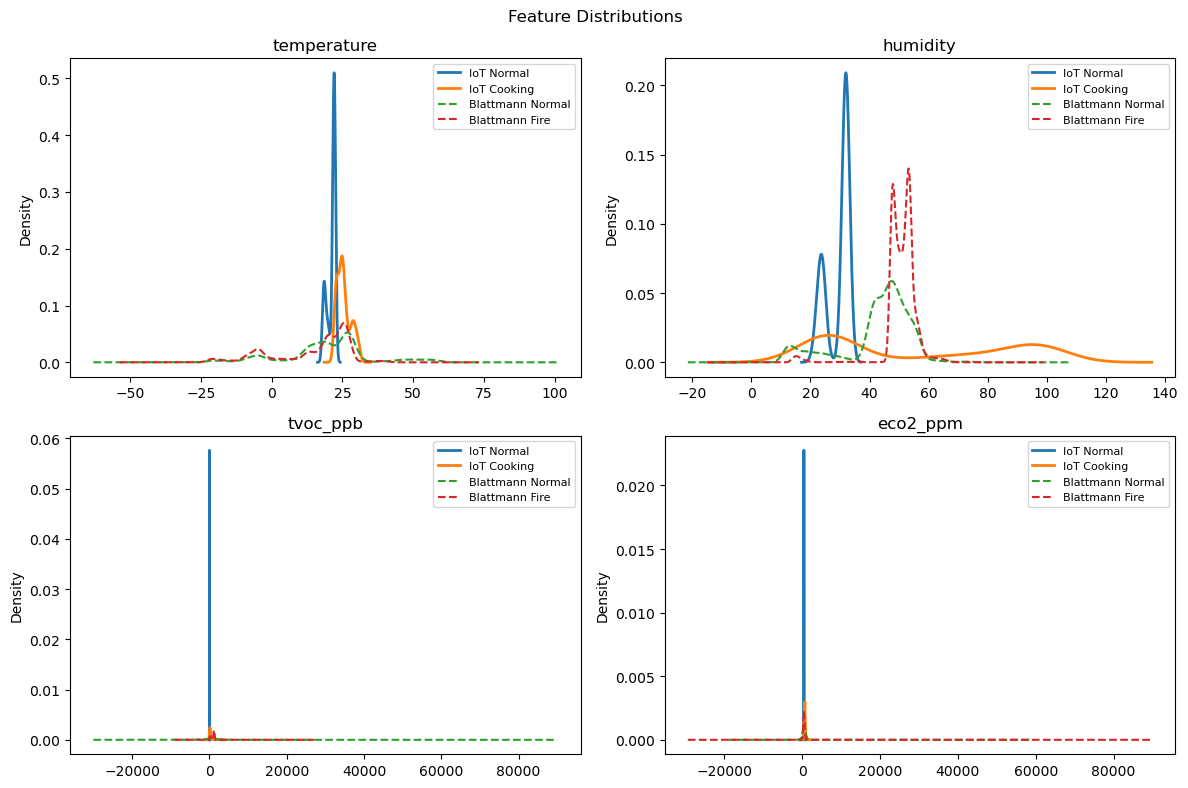

In [35]:
# Plot feature distributions per class and dataset.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions')

for ax, feature in zip(axes.flat, feature_col):
    for class_id, class_name in [(0, 'Normal'), (1, 'Cooking')]:
        values = iot_data[iot_data['class_id'] == class_id][feature]
        if len(values) > 1:
            values.plot.kde(ax=ax, label=f'IoT {class_name}', linewidth=2)

    for class_id, class_name in [(0, 'Normal'), (2, 'Fire')]:
        values = blattmann_data[blattmann_data['class_id'] == class_id][feature]
        if len(values) > 1:
            values.plot.kde(ax=ax, label=f'Blattmann {class_name}', linewidth=1.5, linestyle='--')

    ax.set_title(feature)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


#### 5. Split Each Dataset Separately
Split IoT and Blattmann separately before combining training data, so each source keeps its own test set for evaluation.

In [36]:
# Split each dataset separately, then combine training data in memory.
X_blattmann_train, X_blattmann_test, y_blattmann_train, y_blattmann_test = train_test_split(
    blattmann_data[feature_col],
    blattmann_data['class_id'],
    test_size=0.2,
    random_state=random_state,
    stratify=blattmann_data['class_id']
)

X_iot_train, X_iot_test, y_iot_train, y_iot_test = train_test_split(
    iot_data[feature_col],
    iot_data['class_id'],
    test_size=0.2,
    random_state=random_state,
    stratify=iot_data['class_id']
)

# Combine training data from both datasets in memory without saving to disk.
X_train = pd.concat([X_blattmann_train, X_iot_train], ignore_index=True)
y_train = pd.concat([y_blattmann_train, y_iot_train], ignore_index=True)

print('Train:', len(y_train))
print('Blattmann test:', len(y_blattmann_test))
print('IoT test:', len(y_iot_test))

for class_id, class_name in enumerate(class_names):
    count = (y_train == class_id).sum()
    if count:
        print(f'{class_name}: {count}')


Train: 50543
Blattmann test: 12526
IoT test: 110
Normal: 14474
Cooking: 263
Fire: 35806


#### 6. Scale Features
Scale the features using the training data only. This is important for SVM because margin and kernel calculations are affected by feature magnitude.

In [37]:
# Fit scaler on train only - applying to test avoids data leakage, then transform both test sets.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_blattmann_test_sc = scaler.transform(X_blattmann_test)
X_iot_test_sc = scaler.transform(X_iot_test)

joblib.dump(scaler, notebook_folder / 'scaler_svm.joblib')


['C:\\Users\\waqar\\SEP4\\System\\MlServer\\waqars_model\\scaler_svm.joblib']

#### 7. Tune SVM Settings
Compare a small set of SVM configurations using a stratified training sample. This is done because full SVM cross-validation on the complete training set is computationally expensive and can take a long time, especially with non-linear kernels. The sample keeps the class balance for model selection, while the final SVM is still trained on the full training data.

C:\Users\waqar\AppData\Local\Temp\ipykernel_28280\622591058.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min(len(group), 1500), random_state=random_state))


Tuning sample size: 3263
class_id
0    1500
1     263
2    1500


,kernel,C,gamma,mean_f1_macro,std_f1_macro
2,rbf,1.0,scale,0.9070,0.0080
1,linear,1.0,scale,0.6120,0.0242
0,linear,0.1,scale,0.4481,0.0007


Best SVM settings: {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}


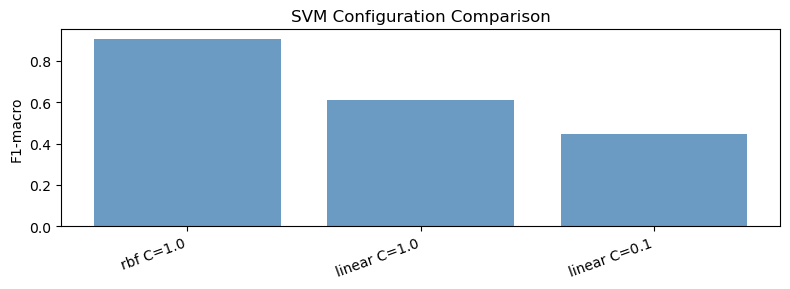

In [38]:
# Compare a few SVM configurations with faster cross-validation on a stratified sample.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
tuning_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

tuning_data = pd.DataFrame(X_train_sc, columns=feature_col)
tuning_data['class_id'] = y_train.to_numpy()

tuning_sample = (
    tuning_data
    .groupby('class_id', group_keys=False)
    .apply(lambda group: group.sample(n=min(len(group), 1500), random_state=random_state))
    .sample(frac=1, random_state=random_state)
)

X_tune = tuning_sample[feature_col]
y_tune = tuning_sample['class_id']

print('Tuning sample size:', len(y_tune))
print(y_tune.value_counts().sort_index().to_string())

svm_options = [
    {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'},
    {'kernel': 'linear', 'C': 1.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
]
svm_scores = []

for params in svm_options:
    candidate = SVC(**params, class_weight='balanced', random_state=random_state)
    scores = cross_val_score(candidate, X_tune, y_tune, cv=tuning_skf, scoring='f1_macro')
    svm_scores.append({
        **params,
        'mean_f1_macro': scores.mean(),
        'std_f1_macro': scores.std(),
    })

svm_results = pd.DataFrame(svm_scores).sort_values('mean_f1_macro', ascending=False)
display(svm_results.round(4))

best_params = svm_results.iloc[0][['kernel', 'C', 'gamma']].to_dict()
print('Best SVM settings:', best_params)

plt.figure(figsize=(8, 3))
labels = svm_results.apply(lambda row: f"{row['kernel']} C={row['C']}", axis=1)
plt.bar(labels, svm_results['mean_f1_macro'], color='steelblue', alpha=0.8)
plt.ylabel('F1-macro')
plt.title('SVM Configuration Comparison')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


#### 8. Train SVM
Train the final SVM model using the selected configuration and save the model artifact.

In [39]:
# Train the SVM model.
svm = SVC(
    **best_params,
    class_weight='balanced',
    random_state=random_state
)

svm.fit(X_train_sc, y_train)

joblib.dump(svm, notebook_folder / 'model_svm.joblib')


['C:\\Users\\waqar\\SEP4\\System\\MlServer\\waqars_model\\model_svm.joblib']

#### 9. Cross-Validation
Evaluate the final SVM configuration with stratified cross-validation on the tuning sample. This keeps the runtime practical for SVM, while the final model itself is trained on the full training data.

Cross-validation F1-macro: 0.9070 +/- 0.0080


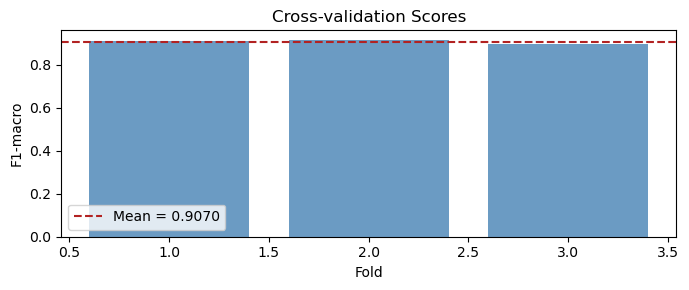

In [40]:
# Run cross-validation on the tuning sample to keep SVM runtime practical.
cv_scores = cross_val_score(svm, X_tune, y_tune, cv=tuning_skf, scoring='f1_macro')

print(f'Cross-validation F1-macro: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

plt.figure(figsize=(7, 3))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(cv_scores.mean(), color='firebrick', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1-macro')
plt.title('Cross-validation Scores')
plt.legend()
plt.tight_layout()
plt.show()


#### 10. Test Set Evaluation
Evaluate predictions separately on the Blattmann and IoT test sets using precision, recall, and F1-score.

In [41]:
# Predict and evaluate on both test sets.
y_blattmann_pred = svm.predict(X_blattmann_test_sc)
y_iot_pred = svm.predict(X_iot_test_sc)

print('Blattmann test set')
print(classification_report(y_blattmann_test, y_blattmann_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))

print('IoT test set')
print(classification_report(y_iot_test, y_iot_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))


Blattmann test set
              precision    recall  f1-score   support

      Normal       0.73      0.98      0.84      3575
     Cooking       0.00      0.00      0.00         0
        Fire       0.99      0.85      0.92      8951

    accuracy                           0.89     12526
   macro avg       0.57      0.61      0.59     12526
weighted avg       0.92      0.89      0.89     12526

IoT test set
              precision    recall  f1-score   support

      Normal       0.98      0.93      0.95        44
     Cooking       0.96      0.98      0.97        66
        Fire       0.00      0.00      0.00         0

    accuracy                           0.96       110
   macro avg       0.64      0.64      0.64       110
weighted avg       0.96      0.96      0.96       110



#### 11. IoT Device Evaluation
Show the IoT test result separately because this dataset represents the target device readings most directly.

In [42]:
print('IoT device test set')
print(classification_report(y_iot_test, y_iot_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))


IoT device test set
              precision    recall  f1-score   support

      Normal       0.98      0.93      0.95        44
     Cooking       0.96      0.98      0.97        66
        Fire       0.00      0.00      0.00         0

    accuracy                           0.96       110
   macro avg       0.64      0.64      0.64       110
weighted avg       0.96      0.96      0.96       110



#### 12. Confusion Matrices
Plot confusion matrices to see which classes are predicted correctly and where mistakes happen.

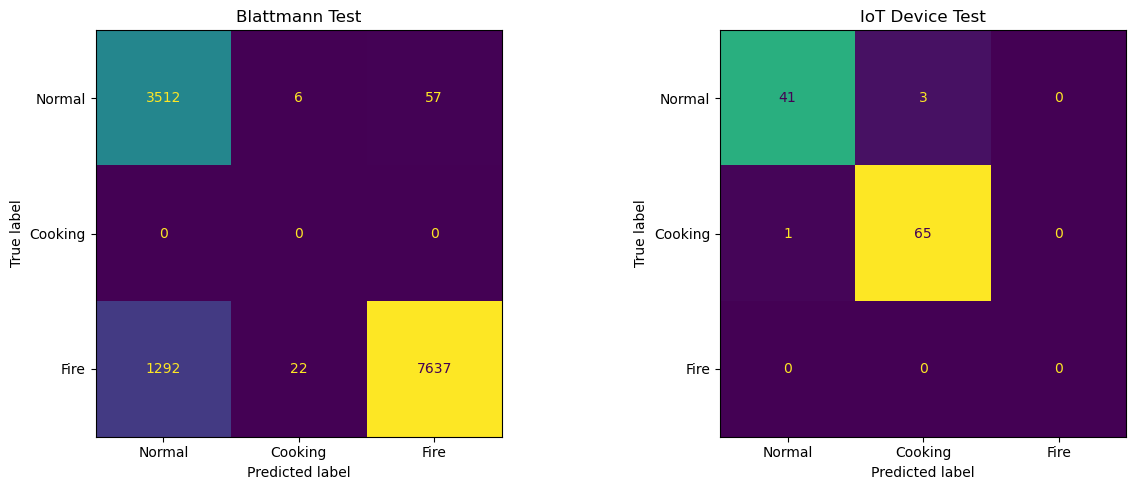

Cooking -> Fire errors in IoT: 0


In [43]:
# Plot confusion matrices for both test sets.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_blattmann_test, y_blattmann_pred, 'Blattmann Test'),
    (axes[1], y_iot_test, y_iot_pred, 'IoT Device Test'),
]:
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print('Cooking -> Fire errors in IoT:', confusion_matrix(y_iot_test, y_iot_pred, labels=[0, 1, 2])[1][2])


#### 13. Overfitting Check
Compare full-training F1-score with the sample-based cross-validation F1-score as a lightweight overfitting check. The held-out test reports remain the main evaluation results.

In [44]:
# Check for overfitting by comparing train and cross-validation scores.
train_f1 = f1_score(y_train, svm.predict(X_train_sc), average='macro')
cv_f1 = cv_scores.mean()
gap = train_f1 - cv_f1

print(f'Train F1: {train_f1:.4f}  |  CV F1: {cv_f1:.4f}  |  Gap: {gap:.4f}')
print('no overfitting' if gap < 0.02 else 'mild overfitting' if gap < 0.05 else 'overfitting detected')


Train F1: 0.8496  |  CV F1: 0.9070  |  Gap: -0.0575
no overfitting


#### 14. Final Notes

The purpose of this notebook is to test whether an SVM can classify smoke-related sensor readings using the same prepared data and evaluation setup as the Random Forest and KNN models. The main performance indicators are macro F1-score, per-class precision and recall, and the confusion matrices.

Because SVM depends on margins and kernel-based distances, scaling is required. SVM tuning and cross-validation use a stratified sample to avoid very long runtimes, but final training and held-out test evaluation still use the full train/test split. The final result should be compared with the Random Forest and KNN models to decide whether SVM provides better separation between Normal, Cooking, and Fire cases.